# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())
print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())
print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  En caso de tener una alta proporción de datos ausentes, se recomienda considerar eliminar la columna o excluirla del análisis esto debido a la alta proporción de datos faltantes
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  En caso de una proporción de entre el 5% y 30% de datos faltantes la recomendación es investigar la causa de los datos ausentes antes de decidir una estrategia de imputación o eliminación, ya que podrían afectar los resultados del análisis
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 En este caso tendriamos un impacto bajo en el análisis, por lo tanto se podría imputar utilizando la media, mediana o moda según corresponda, incluso conservar los nulos si esto no afectan el objetivo del análisis.
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- city 0.11725, churn_date 0.88350
- date        0.00125, duration    0.55190, length      0.44740 
- Indica qué harías: ¿imputar, eliminar, ignorar?
- En el caso de City podria imputar puesto que la proporción es baja.
- Para churn_date debido a la proporción eliminar del análisis
- Date imputar
- Para duration y length debido a las proporciones de cada uno considero es mejor eliminar del análisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` La columna user_id contiene identificadores únicos de usuarios. No se observan valores anómalos ya que corresponde a una variable de identificación. 
- La columna `age` La columna age presenta valores dentro de un rango esperado para usuarios. No se identifican sentinels evidentes como edades negativas o extremadamente altas.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas `id` y `user_id` funcionan como identificadores. Los valores se encuentran dentro de rangos consistentes y no presentan indicios de datos faltantes o valores anómalos, por lo que no requieren limpieza adicional.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f'\nValores únicos de {columna}:')
    print(users[columna].value_counts(dropna=False))



Valores únicos de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`contiene varias ciudades válidas (Bogotá, CDMX, Medellín, GDL, Cali y MTY), pero presenta 469 valores nulos y 96 registros con el valor `?`, lo que sugiere datos faltantes o información capturada incorrectamente. Se recomienda reemplazar `?` por valores nulos para tratarlos de forma consistente y posteriormente evaluar una estrategia de imputación o exclusión.
- La columna `plan` únicamente contiene las categorías esperadas (`Basico` y `Premium`) y no presenta valores inesperados ni inconsistencias aparentes, para esta variable no se requiere limpieza adicional.

In [16]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` esta columna únicamente contiene las categorías esperadas (`text` y `call`) y no presenta valores inesperados ni inconsistencias aparentes, esta variable no requiere limpieza adicional.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- La columna city contiene 469 valores nulos y 96 registros con el valor ?, el cual puede considerarse un sentinel porque no representa una ciudad válida y probablemente se utilizó para indicar información desconocida o no registrada.
  
- La columna duration presenta registros con valor 0. Es necesario verificar si representan sesiones válidas sin duración o errores de captura de datos.
  
- La columna length presenta valores 0, que podrían indicar ausencia de consumo o registros incompletos. Además, existen algunos valores considerablemente altos que conviene revisar para confirmar que corresponden a observaciones reales.
  
- La columna plan únicamente contiene las categorías esperadas (Basico y Premium), por lo que no se identifican valores inválidos ni sentinels.
  
- Las columnas id y user_id contienen identificadores dentro de rangos consistentes y no muestran anomalías aparentes.

- ¿Qué acción tomarías?
- En la columna city, reemplazaría el valor ? por NaN para unificar el tratamiento de los datos faltantes. Posteriormente evaluaría si conviene imputar los valores faltantes utilizando información adicional del usuario o mantenerlos como nulos.

- En la columna duration, investigaría el significado de los valores 0 antes de eliminarlos o imputarlos. Si representan sesiones sin actividad, podrían conservarse; si corresponden a errores de captura, deberían corregirse o excluirse.

- En la columna length, validaría si los valores 0 y los valores extremadamente altos son coherentes con la operación del negocio. Dependiendo del resultado, podrían mantenerse, corregirse o analizarse como valores atípicos.

- No realizaría acciones sobre las columnas plan, id y user_id, ya que no presentan indicios de problemas de calidad de datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se observan registros correspondientes a los años 2022, 2023, 2024 y 2026. Sin embargo, la información proporcionada indica que los datos sólo están registrados hasta 2024, por lo que los 40 registros del año 2026 son inconsistentes y posiblemente resultado de errores de captura o procesamiento. Estos registros deben revisarse y corregirse antes de continuar con el análisis para evitar conclusiones incorrectas.. 

In [20]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`, todos los registros corresponden al año 2024, con un total de 39,950 observaciones. No se identifican años fuera del rango esperado, por lo que esta columna no presenta inconsistencias aparentes relacionadas con las fechas y puede considerarse válida para el análisis.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Sí, aparecen años fuera del rango esperado. En la columna reg_date se identificaron 40 registros correspondientes al año 2026, mientras que se indicó que la información disponible llega únicamente hasta 2024. Esto sugiere la existencia de errores de captura, carga o transformación de datos.
  
- ¿Qué harías con ellas?
- Como primera acción, revisaría los registros originales para verificar si el año fue capturado incorrectamente (por ejemplo, 2026 en lugar de 2024). Si es posible recuperar la fecha correcta a partir de la fuente de datos, realizaría la corrección correspondiente. En caso de no poder validar la información, recomendaría excluir temporalmente esos registros del análisis para evitar sesgos o resultados incorrectos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_missing'] = usage['duration'].isna()
print(pd.crosstab(usage['type'], usage['duration_missing'], normalize='index') * 100)

duration_missing       False      True 
type                                   
call              100.000000   0.000000
text                0.072424  99.927576


In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_missing'] = usage['length'].isna()
print(pd.crosstab(usage['type'], usage['length_missing'], normalize='index') * 100)

length_missing       False      True 
type                                 
call              0.067009  99.932991
text            100.000000   0.000000


Diagnostico para `duration` y `length`;

Los valores nulos en las columnas duration y length no son errores de calidad de datos ni faltantes aleatorios. Se observa una dependencia prácticamente total con la variable type: los registros de tipo call contienen información de duración pero no de longitud, mientras que los registros de tipo text contienen información de longitud pero no de duración. Esto indica que los nulos son de tipo MAR (Missing At Random) e incluso podrían considerarse nulos estructurales generados por la naturaleza de los datos. Por esta razón, se recomienda conservar los valores nulos y no reemplazarlos ni eliminarlos, ya que representan correctamente la ausencia esperada de información para cada tipo de registro.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

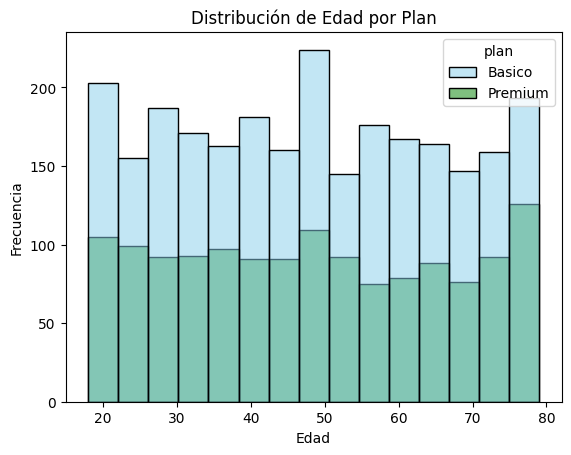

In [37]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'],bins=15)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución
  1. La distribución de edad es muy similar entre los planes básico y premium.
  2. No se observa concentración especifica de usuarios jovenes o mayores en alguno de los planes.
  3. El plan básico concentra una mayor cantidad de usuarios en todos los rangos de edad.
  4. La distribución de edades es relativamente uniforme y no muestra un sesgo claro hacia la izquierda o hacia la derecha.

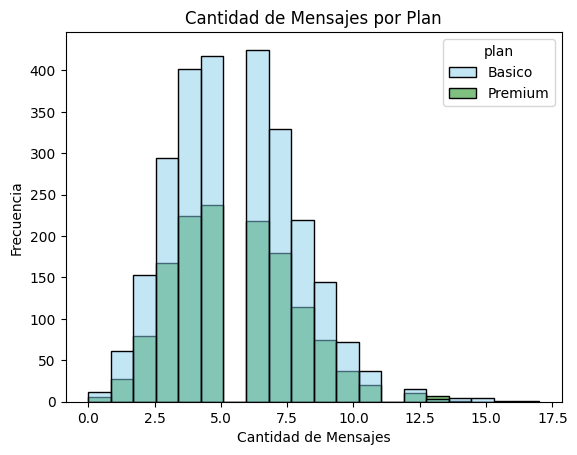

In [39]:
# Histograma para visualizar la 
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
1. Los usuarios de ambos planes muestran patrones de mensajería muy similares.
2. La mayor concentración de usuarios envía entre 4 y 7 mensajes.
3. Existen pocos usuarios con cantidades muy altas de mensajes, generando una cola hacia la derecha.
4. La distribución presenta un sesgo positivo (hacia la derecha).
5. El plan Básico tiene una mayor frecuencia de usuarios, aunque no se observan diferencias importantes en el comportamiento de envío de mensajes entre los planes.

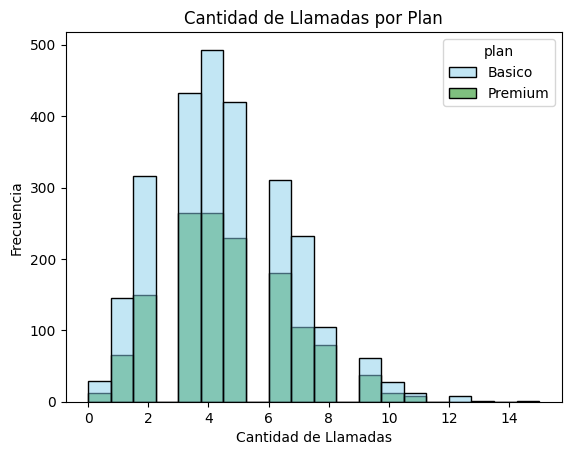

In [48]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
1. Los usuarios de los planes Básico y Premium presentan patrones de llamadas muy similares.
2. La mayoría de los clientes realiza entre 3 y 6 llamadas, siendo 4 llamadas aproximadamente el valor más frecuente.
3. Existen pocos usuarios con cantidades elevadas de llamadas, generando una cola hacia valores altos.
4. La distribución es asimétrica con sesgo positivo (hacia la derecha).
5. Aunque el plan Básico registra una mayor frecuencia de usuarios, no se observan diferencias importantes en el comportamiento de llamadas entre ambos planes.
   
- Distribución
- Las distribuciones son muy similares, sin evidencia de diferencias relevantes en el patron de uso.

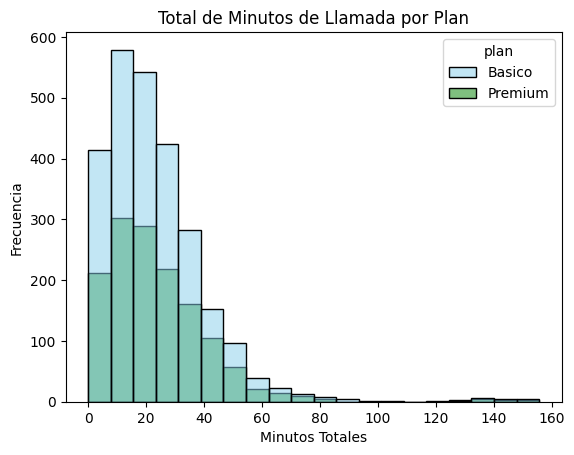

In [47]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Total de Minutos de Llamada por Plan')
plt.xlabel('Minutos Totales')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
1. La mayoría de los usuarios acumula entre 5 y 30 minutos de llamada, independientemente del plan contratado.
2. Las distribuciones de los planes Básico y Premium son muy similares, por lo que no se observan diferencias importantes en el consumo de minutos.
3. La distribución presenta un fuerte sesgo positivo (hacia la derecha), con una cola larga hacia valores altos.
4. Existen algunos usuarios con consumos significativamente mayores al promedio, lo que sugiere la presencia de valores atípicos.
5. El plan Básico presenta una mayor frecuencia de usuarios en la muestra analizada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

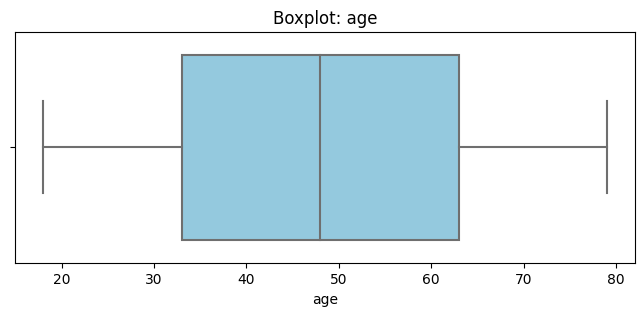

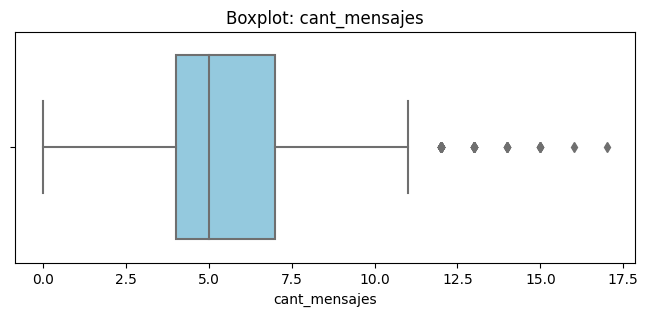

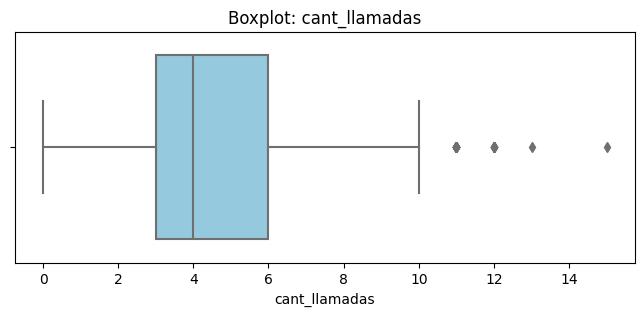

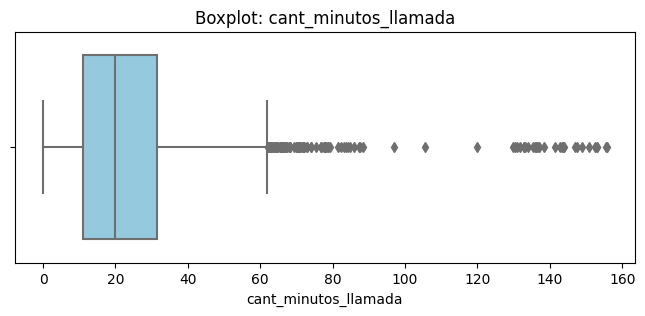

In [49]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(
        x=user_profile[col], color='skyblue'
    )
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers, todas las edades se encuentran dentro del rango esperado.
- cant_mensajes: No se observan valores atípicos inferiores.
- Existen varios outliers superiores a partir de aproximadamente 12 mensajes, correspondientes a usuarios con un uso intensivo del servicio de mensajería.
- La distribución presenta un sesgo positivo (hacia la derecha).
- cant_llamadas: Existen algunos valores atípicos superiores asociados a usuarios que realizan una cantidad inusualmente alta de llamadas.
- La distribución presenta un sesgo positivo (hacia la derecha).
- Los outliers parecen representar comportamientos reales de uso, por lo que se recomienda conservarlos.
- cant_minutos_llamada: La variable total_minutos_llamada presenta una gran cantidad de valores atípicos superiores.
- La mayoría de los usuarios consume pocos minutos de llamada, mientras que un grupo reducido registra consumos muy elevados.
- La distribución es fuertemente asimétrica con sesgo positivo (hacia la derecha).
- Los outliers parecen reflejar diferencias reales en los hábitos de consumo de los usuarios.
- Se recomienda mantener estos valores ya que aportan información valiosa sobre los clientes de alto uso.

In [51]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    maximo = user_profile[col].max()
    print(f'\nVariable: {col}')
    print(f'Q1: {Q1:.2f}')
    print(f'Q3: {Q3:.2f}')
    print(f'IQR: {IQR:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Máximo observado: {maximo:.2f}')




Variable: cant_mensajes
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite superior: 11.50
Máximo observado: 17.00

Variable: cant_llamadas
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite superior: 10.50
Máximo observado: 15.00

Variable: cant_minutos_llamada
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite superior: 61.86
Máximo observado: 155.69


In [52]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  Se recomienda mantener outliers, los valores atípicos parecen representar comportamientos reales de usuarios y no errores de captura
- cant_llamadas: mantener o no outliers, porqué?
  Si, se recomienda mantenerlos, los outlier parecen representar comportamientos reales de uso.
- cant_minutos_llamada: mantener o no outliers, porqué?
  Mantener debido a que reflejan diferencias reales de los hábitos de consumo de los usuarios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [54]:
# Crear columna grupo_uso
grupo_uso = []
for i in range(len(user_profile)):
    llamadas = user_profile.loc[i, 'cant_llamadas']
    mensajes = user_profile.loc[i, 'cant_mensajes']
    if llamadas < 5 and mensajes < 5:
        grupo_uso.append('Bajo uso')
    elif llamadas < 10 and mensajes < 10:
        grupo_uso.append('Uso medio')
    else:
        grupo_uso.append('Alto uso')
user_profile['grupo_uso'] = grupo_uso

In [55]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [65]:
# Crear columna grupo_edad
grupo_edad = []
for i in range(len(user_profile)):
    edad = user_profile.loc[i, 'age']
    if edad < 30:
        grupo_edad.append('Joven')
    elif edad < 60:
        grupo_edad.append('Adulto')
    else:
        grupo_edad.append('Adulto Mayor')
user_profile['grupo_edad'] = grupo_edad


In [66]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

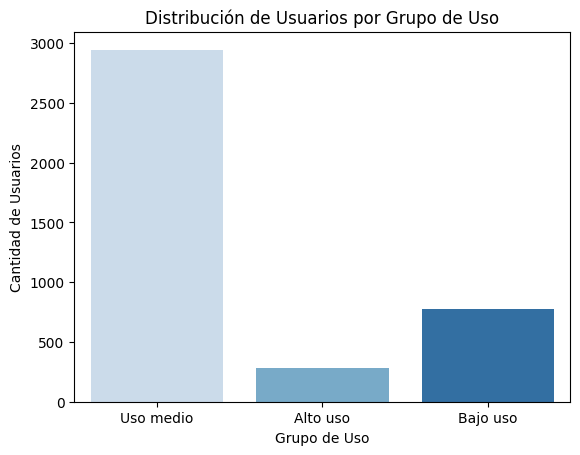

In [67]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='Blues')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

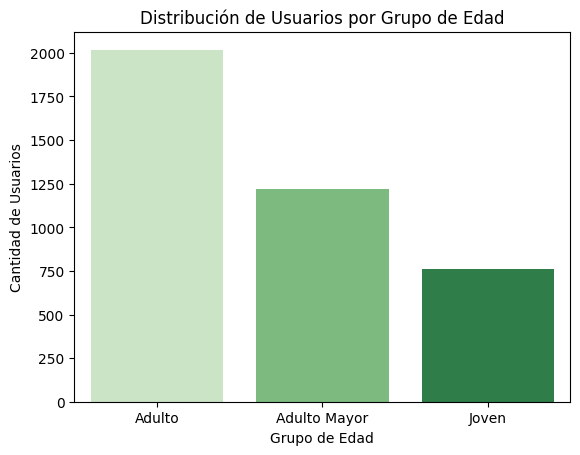

In [68]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='Greens')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- Durante la etapa de exploración y limpieza se identificaron algunos valores atípicos en las variables de uso:

cant_mensajes
cant_llamadas
cant_minutos_llamada

Sin embargo, estos valores no fueron considerados errores de captura ni inconsistencias en la base de datos. Los análisis mediante histogramas y boxplots mostraron que corresponden a usuarios con niveles de consumo significativamente superiores al promedio, pero plausibles dentro del contexto del negocio.
Por esta razón, se decidió conservar los outliers, ya que representan segmentos de clientes de alto valor y proporcionan información relevante para la toma de decisiones comerciales.


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- Los clientes se segmentaron en las categorias; joven, adulto y adulto mayor.
- La mayoría de los clientes se concentra en los grupos de uso medio y adultos.
- La distribución de edades es relativamente uniforme, sin una concentración marcada en un grupo específico.
- No se identificó una relación fuerte entre la edad y el patrón de uso del servicio.
- Los usuarios de los planes Básico y Premium muestran comportamientos muy similares en términos de llamadas, mensajes y minutos consumidos.
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
  Los clientes mas valiosos para ConnectaTel son los clientes con alto uso ya que representan el segmento de mayor interés para la compañía porque:

Consumen más minutos de llamada.
Generan más actividad en mensajes.
Son potencialmente los usuarios con mayor contribución a los ingresos.
Presentan oportunidades para programas de fidelización y venta de servicios adicionales.

Además, los usuarios identificados como outliers de uso podrían constituir un segmento premium con necesidades específicas de comunicación.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Los análisis identificaron:
Mensajes:
Usuarios con más de 12 mensajes, superando claramente al usuario promedio.
Llamadas:
Usuarios con más de 10 llamadas, alcanzando hasta 15 llamadas en algunos casos.
Minutos de llamada:
Usuarios con consumos superiores a los límites establecidos por el método IQR.
Algunos clientes registran consumos extremadamente altos frente al comportamiento general de la población.

Implicaciones para el negocio
Estos usuarios representan:
Clientes altamente comprometidos con el servicio.
Potenciales candidatos para planes premium.
Oportunidades para desarrollar ofertas especializadas.
Posibles embajadores de la marca debido a su nivel de utilización.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
1. Diseñar planes para usuarios de alto consumo
Crear paquetes con:
Más minutos incluidos.
Beneficios adicionales por permanencia.
Descuentos escalonados por uso.
2. Impulsar migraciones hacia planes superiores:
Dado que los patrones de uso entre planes son similares, existen oportunidades para incentivar a usuarios del plan Básico a migrar hacia opciones con mayor valor agregado.
Implementar estrategias de segmentación
3. Personalizar promociones según:
Grupo de edad.
Nivel de uso.
Intensidad de consumo de llamadas y mensajes.
4. Monitorear continuamente los usuarios de alto uso
Estos clientes pueden representar una fuente importante de ingresos y deben considerarse prioritarios en programas de retención.

✍️ **Escribe aquí tu análisis ejecutivo:**

El análisis reveló que los usuarios de ConnectaTel presentan comportamientos relativamente similares entre los planes Básico y Premium, mientras que las mayores diferencias se encuentran en la intensidad de uso individual. Los valores atípicos identificados corresponden a clientes de alto consumo y representan una oportunidad estratégica para la empresa. La segmentación por edad y uso permitió identificar grupos de clientes con características diferenciadas, siendo los usuarios de alto uso el segmento con mayor potencial comercial. Se recomienda desarrollar ofertas específicas, estrategias de fidelización y acciones de upselling que permitan maximizar el valor generado por estos clientes y mejorar la rentabilidad de la cartera.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`